# Sign Language Letter Recognition Using Machine Learning

## Project Overview

This project uses machine learning to recognize static sign language letters from hand landmark coordinates.

MediaPipe is used to extract hand landmark coordinates, which are then used as features for a machine learning model. The model learns patterns in these coordinates and predicts the corresponding sign language letter.

The dataset contains normalized hand landmark coordinates for 24 static sign language classes. Dynamic signs such as J and Z are excluded because they require hand movement that cannot be represented by a single static set of landmarks.

## 1. Importing Libraries

We import the Python libraries

In [2]:
import pandas as pd

## 2. Loading the Dataset

The normalized dataset contains hand landmark coordinates and their corresponding sign language labels.

We use Pandas to load the CSV file into a DataFrame.

In [3]:
df = pd.read_csv("normalized_dataset.csv")

## 3. Exploring the Dataset

Before training the model, we inspect the dataset to understand its structure, features, and labels.

In [8]:
df.head()


,x0,y0,z0,x1,y1,z1,x2,y2,z2,x3,...,x18,y18,z18,x19,y19,z19,x20,y20,z20,label
0,0.0,0.0,0.0,0.262514,-0.169952,-0.085919,0.462697,-0.415486,-0.113627,0.464281,...,-0.235152,-0.599986,-0.176400,-0.187635,-0.424168,-0.152603,-0.135141,-0.294854,-0.097718,A
1,0.0,0.0,0.0,0.288296,-0.162903,-0.071021,0.476796,-0.435767,-0.087792,0.506385,...,-0.221652,-0.678187,-0.171459,-0.168404,-0.489134,-0.148450,-0.140973,-0.315515,-0.093898,A
2,0.0,0.0,0.0,0.285874,-0.138654,-0.092324,0.494867,-0.389284,-0.123929,0.502033,...,-0.172821,-0.665593,-0.173112,-0.134013,-0.477491,-0.136889,-0.123960,-0.322718,-0.073458,A
3,0.0,0.0,0.0,0.228196,-0.076306,-0.120714,0.466931,-0.346911,-0.157960,0.521302,...,-0.214673,-0.594404,-0.217807,-0.194003,-0.380896,-0.189775,-0.184793,-0.236568,-0.123909,A
4,0.0,0.0,0.0,0.261574,-0.091177,-0.113740,0.490670,-0.359000,-0.143275,0.527927,...,-0.204442,-0.637715,-0.188697,-0.162141,-0.451554,-0.159645,-0.150603,-0.298077,-0.094856,A


### Dataset Columns

The dataset contains 63 hand landmark coordinate features and one label column.

The coordinate features represent the x, y, and z coordinates of 21 hand landmarks:

- x0, y0, z0
- x1, y1, z1
- ...
- x20, y20, z20

The `label` column contains the corresponding sign language letter.

In [ ]:
df.columns

## 4. Preparing the Features and Target

For supervised learning, we separate the dataset into:

- **Features (`X`)** — the 63 hand landmark coordinates used as input to the model.
- **Target (`y`)** — the sign language letter that the model is trained to predict.

The `label` column is excluded from the features because it is the answer we want the model to learn to predict.

In [ ]:
X = df.drop("label", axis=1)
y = df["label"]


### Checking the Dataset Dimensions

We check the shape of `X` and `y` to confirm that the features and labels contain the expected number of samples.

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

### Checking the Classes

The target variable contains 24 static sign language classes. Dynamic signs such as J and Z are excluded from this dataset.

In [9]:
y.unique()

<StringArray>
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P',
 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']
Length: 24, dtype: str

## 5. Splitting the Dataset

The dataset is divided into training and testing sets.

The training set is used to teach the model the patterns in the hand landmark coordinates, while the testing set contains unseen examples used to evaluate how well the model generalizes.

We use an 80/20 split:

- 80% for training
- 20% for testing

Stratification is used to maintain the distribution of the 24 classes in both sets.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)




### Checking the Split

We check the dimensions of the resulting training and testing sets.

In [ ]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

## 6. Building the Random Forest Model

A Random Forest classifier is used as one of the machine learning models for this project.

Random Forest combines multiple decision trees. Each tree makes a prediction based on the hand landmark coordinates, and the forest combines the results to produce the final predicted class.

We begin with 100 decision trees.

In [7]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

### Model Training

The model is now trained using the training features and their corresponding labels.

During training, the Random Forest learns patterns in the 63 hand landmark coordinates that correspond to the different sign language classes.

In [12]:
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

## 7. Making Predictions

After training the model, we use the testing data to make predictions.

The testing features have not been used during training, so they allow us to evaluate how well the model performs on unseen hand landmark coordinates.

In [13]:
y_pred = model.predict(X_test)

## 8. Evaluating the Model

We compare the model's predictions with the actual labels in the testing set.

Accuracy tells us the proportion of test samples that the model classified correctly.

In [14]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9378378378378378


### Accuracy Result

The Random Forest model achieved an accuracy of approximately **93.78%** on the test dataset.

This means that the model correctly predicted the sign language letter for approximately 93.78% of the unseen test samples.

## 9. Classification Report

A classification report provides precision, recall, and F1-score for each sign language class.

These metrics give us a more detailed understanding of the model's performance across the different letters.

In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           A       0.88      1.00      0.93        14
           B       0.93      1.00      0.97        14
           C       0.87      1.00      0.93        13
           D       0.95      1.00      0.97        18
           E       1.00      1.00      1.00        17
           F       1.00      0.95      0.97        20
           G       1.00      1.00      1.00        16
           H       0.94      1.00      0.97        17
           I       0.93      1.00      0.97        14
           K       1.00      0.94      0.97        18
           L       1.00      1.00      1.00        15
           M       0.83      0.91      0.87        11
           N       0.80      0.50      0.62         8
           O       1.00      0.88      0.93        16
           P       0.93      1.00      0.97        14
           Q       1.00      0.93      0.96        14
           R       0.88      0.88      0.88        17
           S       1.00    

### Classification Results

The Random Forest achieved an overall test accuracy of approximately **93.78%**.

The classification report shows that the model performs well across most of the sign language classes. Several classes achieved an F1-score of 1.00, indicating excellent classification performance for those classes.

However, some classes performed less strongly. In particular, N had an F1-score of 0.62, while U and V had F1-scores of 0.68 and 0.82 respectively. This suggests that these classes may have hand-coordinate patterns that are more difficult for the model to distinguish.

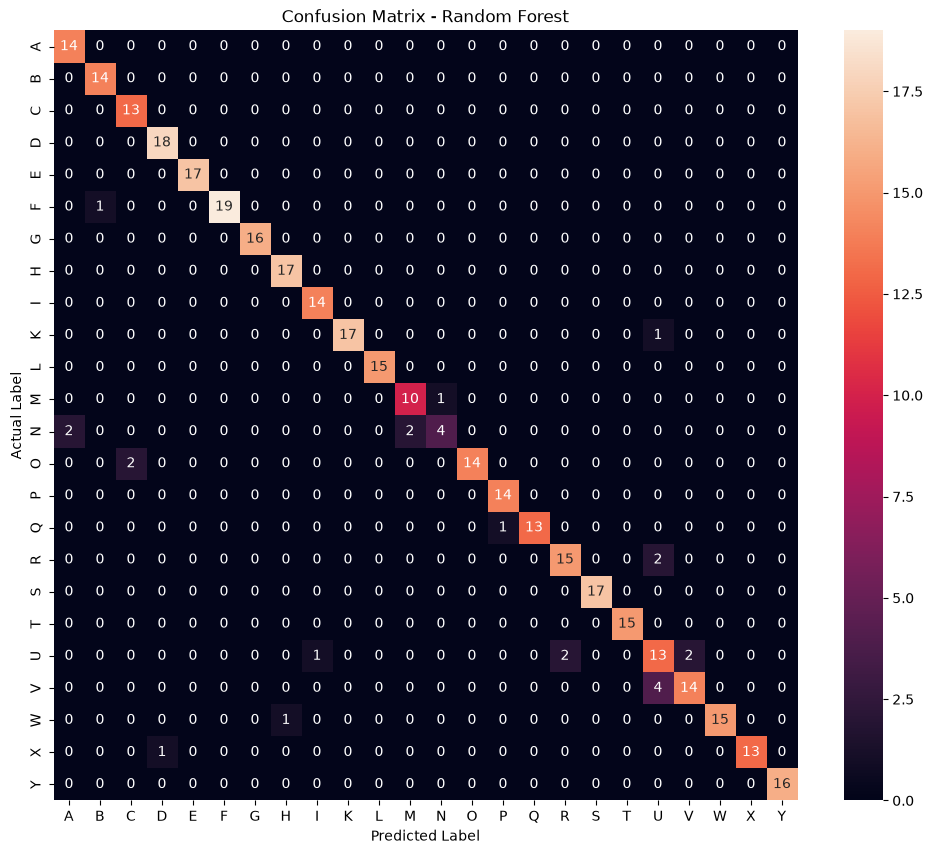

In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Random Forest")
plt.show()

## 11. Saving the Trained Model

The trained Random Forest model is saved so that it can be reused later without retraining it. The saved model can eventually be loaded by the application that receives hand landmark coordinates from the webcam.

In [18]:
import joblib

joblib.dump(model, "random_forest_model.pkl")

['random_forest_model.pkl']

## 12. Loading the Saved Model

The saved Random Forest model can be loaded back into Python and used to make predictions without training the model again.

In [19]:
loaded_model = joblib.load("random_forest_model.pkl")

print("Model loaded successfully.")

Model loaded successfully.
